In [1]:
import sys
print(sys.executable)

d:\Desktop\MLT Project\disaster_tweets\.venv\Scripts\python.exe


In [2]:
import pandas as pd

df=pd.read_csv("../dataset/train.csv")


In [3]:
df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [4]:
print(df.shape)

(7613, 5)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        7613 non-null   int64
 1   keyword   7552 non-null   str  
 2   location  5080 non-null   str  
 3   text      7613 non-null   str  
 4   target    7613 non-null   int64
dtypes: int64(2), str(3)
memory usage: 297.5 KB


In [6]:
df.isnull().sum()

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

In [7]:
df["target"].value_counts(normalize=True)

target
0    0.57034
1    0.42966
Name: proportion, dtype: float64

In [8]:
df["keyword"].nunique()

221

In [9]:
df["location"].nunique()

3341

In [10]:
df["keyword"].value_counts().head(50)

keyword
fatalities             45
armageddon             42
deluge                 42
body%20bags            41
damage                 41
harm                   41
sinking                41
collided               40
evacuate               40
fear                   40
outbreak               40
siren                  40
twister                40
windstorm              40
collision              39
derailment             39
earthquake             39
explosion              39
famine                 39
flames                 39
hellfire               39
sinkhole               39
sunk                   39
weapon                 39
weapons                39
whirlwind              39
wreckage               39
wrecked                39
ambulance              38
blaze                  38
bombed                 38
deaths                 38
derailed               38
drowned                38
explode                38
fatal                  38
fire                   38
flooding               38
hurr

In [11]:
df["keyword"].value_counts().tail(50)

keyword
arson                    32
blight                   32
cyclone                  32
destroyed                32
detonation               32
drown                    32
electrocute              32
eyewitness               32
forest%20fires           32
hailstorm                32
hijacking                32
mass%20murderer          32
survive                  32
trapped                  32
crushed                  31
devastated               31
hostage                  31
obliterate               31
obliterated              31
suicide%20bomber         31
terrorist                31
trauma                   31
wild%20fires             31
avalanche                30
bioterrorism             30
catastrophic             30
dead                     30
mayhem                   30
survivors                30
annihilation             29
bombing                  29
desolate                 29
first%20responders       29
obliteration             29
seismic                  29
sirens      

In [12]:
keyword_target = (
    df.groupby("keyword")["target"]
      .mean()
      .sort_values(ascending=False)
)

keyword_target.head(20)

keyword
derailment               1.000000
debris                   1.000000
wreckage                 1.000000
outbreak                 0.975000
typhoon                  0.973684
oil%20spill              0.973684
suicide%20bombing        0.969697
suicide%20bomber         0.967742
bombing                  0.931034
rescuers                 0.914286
suicide%20bomb           0.914286
nuclear%20disaster       0.911765
evacuated                0.888889
razed                    0.885714
wildfire                 0.878788
wild%20fires             0.870968
airplane%20accident      0.857143
mass%20murder            0.848485
buildings%20on%20fire    0.848485
forest%20fires           0.843750
Name: target, dtype: float64

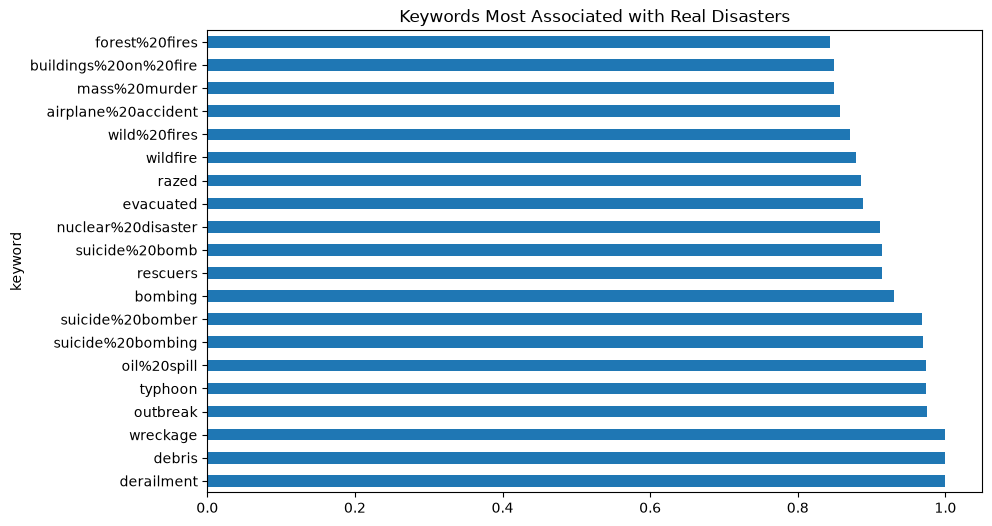

In [13]:
import matplotlib.pyplot as plt

keyword_target.head(20).plot(kind="barh", figsize=(10,6))
plt.title("Keywords Most Associated with Real Disasters")
plt.show()

In [14]:
keyword_stats = (
    df.groupby("keyword", dropna=False)
      .agg(
          count=("target", "size"),
          disaster_rate=("target", "mean")
      )
)

keyword_stats.sort_values(
    "count",
    ascending=False
).head(15)

,count,disaster_rate
keyword,,
NaN,61,0.688525
fatalities,45,0.577778
armageddon,42,0.119048
deluge,42,0.142857
damage,41,0.463415
body%20bags,41,0.024390
harm,41,0.097561
sinking,41,0.195122
twister,40,0.125000


In [15]:
df["location"].value_counts().head(50)


location
USA                  104
New York              71
United States         50
London                45
Canada                29
Nigeria               28
UK                    27
Los Angeles, CA       26
India                 24
Mumbai                22
Washington, DC        21
Kenya                 20
Worldwide             19
Australia             18
Chicago, IL           18
California            17
New York, NY          15
California, USA       15
Everywhere            15
San Francisco         14
Florida               14
United Kingdom        14
Indonesia             13
Los Angeles           13
Washington, D.C.      13
Toronto               12
NYC                   12
Ireland               12
San Francisco, CA     11
Chicago               11
Earth                 11
Seattle               11
London, UK            10
Texas                 10
New York City         10
ss                    10
Atlanta, GA           10
Sacramento, CA        10
London, England       10
Nashville, TN   

In [16]:
df["location"].value_counts().tail(50)


location
iPhone: 33.104393,-96.628624                     1
KADUNA, NIGERIA                                  1
Shady Pines                                      1
Wales, United Kingdom                            1
 Alex/Mika/Leo|18|he/she/they                    1
?Gangsta OC / MV RP; 18+.?                       1
Earth: Senseless nonsense                        1
Not Steven Yeun / AMC.                           1
cody, austin follows ?*?                         1
moss chamber b                                   1
1/10 Taron squad                                 1
Argentina                                        1
 ?currently writing a book?                      1
Lebanon, Tennessee                               1
Pratt-on-Wye                                     1
Somerset, UK                                     1
Atlanta, Georgia                                 1
SF Bay Area, California / Greater Phoenix, AZ    1
Alabama, USA                                     1
Primum non nocere     

In [17]:
location_target = (
    df.groupby("location")["target"]
      .mean()
      .sort_values(ascending=False)
)
location_target.head(50) 

location
 616 Û¢ Kentwood , MI                      1.0
åø\_(?)_/åø                                 1.0
                                            1.0
ÌÏT: 6.488400524109015,3.352798039832285    1.0
ÌÏT: 6.4682,3.18287                         1.0
  News                                      1.0
ÛÊÛÊÛÊ                                   1.0
Û¢III.XII.MMXIÛ¢                          1.0
Û¢901Û¢                                   1.0
Êwagger!ÌominicanÌ÷                       1.0
|| c h i c a g o ||                         1.0
zboyer@washingtontimes.com                  1.0
#BlackLivesMatter                           1.0
#????? Libya#                               1.0
Laguna Beach, Calif.                        1.0
Lahar & Gwalior                             1.0
Lake Monticello, VA                         1.0
Lancaster California                        1.0
Lancaster, CA                               1.0
Lancaster, Pennsylvania, USA                1.0
Lansdale,Pennsylvania          

In [18]:
location_stats = (
    df.groupby("location", dropna=False)
      .agg(
          count=("target", "size"),
          disaster_rate=("target", "mean")
      )
)

location_stats.sort_values(
    "count",
    ascending=False
).head(15)

,count,disaster_rate
location,,
NaN,2533,0.424398
USA,104,0.644231
New York,71,0.225352
United States,50,0.540000
London,45,0.355556
Canada,29,0.448276
Nigeria,28,0.785714
UK,27,0.592593
"Los Angeles, CA",26,0.307692


In [19]:
df[df["location"].isna()]["target"].value_counts()


target
0    1458
1    1075
Name: count, dtype: int64

In [20]:
df["text_length"] = df["text"].str.len()

df["text_length"].describe()

count    7613.000000
mean      101.037436
std        33.781325
min         7.000000
25%        78.000000
50%       107.000000
75%       133.000000
max       157.000000
Name: text_length, dtype: float64

In [21]:
df.groupby("target")["text_length"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,4342.0,95.706817,35.885924,7.0,68.0,101.0,130.0,157.0
1,3271.0,108.113421,29.309854,14.0,88.0,115.0,136.0,151.0


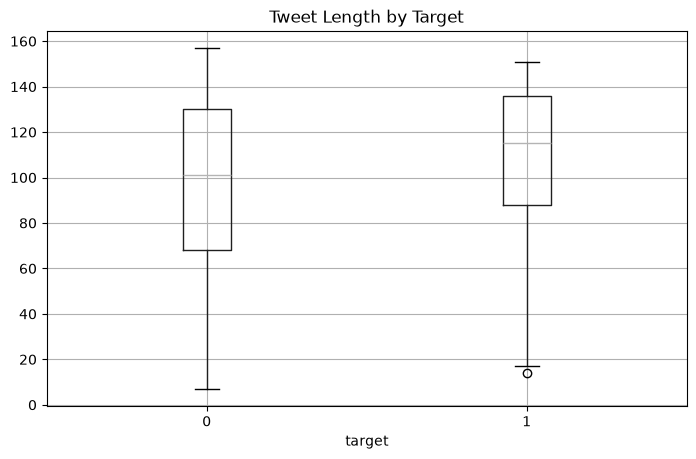

In [22]:
import matplotlib.pyplot as plt

df.boxplot(column="text_length", by="target", figsize=(8,5))

plt.title("Tweet Length by Target")
plt.suptitle("")
plt.show()

In [23]:
df["word_count"] = df["text"].str.split().str.len()

df.groupby("target")["word_count"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,4342.0,14.704744,6.161564,1.0,10.0,15.0,19.0,31.0
1,3271.0,15.167533,5.096806,2.0,11.0,15.0,19.0,30.0


In [24]:
df["has_url"] = df["text"].str.contains(
    r"(https?://|www\.)",
    case=False,
    regex=True
)

df.groupby("target")["has_url"].mean()

C:\Users\Acer\AppData\Local\Temp\ipykernel_32176\3083891445.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["has_url"] = df["text"].str.contains(


target
0    0.414325
1    0.664017
Name: has_url, dtype: float64

In [25]:
df[df["text"].str.contains("http", case=False, na=False)][["text","target"]].head(20)

,text,target
31,@bbcmtd Wholesale Markets ablaze http://t.co/l...,1
32,We always try to bring the heavy. #metal #RT h...,0
33,#AFRICANBAZE: Breaking news:Nigeria flag set a...,1
35,On plus side LOOK AT THE SKY LAST NIGHT IT WAS...,0
37,INEC Office in Abia Set Ablaze - http://t.co/3...,1
38,Barbados #Bridgetown JAMAICA ÛÒ Two cars set ...,1
40,Check these out: http://t.co/rOI2NSmEJJ http:/...,0
44,I wanted to set Chicago ablaze with my preachi...,0
45,I gained 3 followers in the last week. You? Kn...,0
46,How the West was burned: Thousands of wildfire...,1


In [26]:
df[df["has_url"]][["text", "target"]].sample(10, random_state=42)

,text,target
3642,Govt allocating 1.3 bn for flood action: Issue...,1
2843,PennLive - Two families displaced by Mechanics...,1
5248,Refugio oil spill may have been costlier bigge...,1
405,Owner of Chicago-Area Gay Bar Admits to Arson ...,0
2994,NASA MODIS image: Dust storm over Morocco and ...,1
538,.@bigperm28 was drafted by the @Avalanche in 2...,0
5435,Maid charged with stealing Dh30000 from police...,0
3644,I liked a @YouTube video http://t.co/43sXG9Z6x...,1
7612,The Latest: More Homes Razed by Northern Calif...,1
4407,#hot Funtenna: hijacking computers to send da...,0


In [27]:
df["hashtag_count"] = df["text"].str.count("#")

df.groupby("target")["hashtag_count"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,4342.0,0.391525,1.008420,0.0,0.0,0.0,0.0,11.0
1,3271.0,0.520636,1.206805,0.0,0.0,0.0,1.0,13.0


In [28]:
df["at_count"] = df["text"].str.count("@")

df.groupby("target")["at_count"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,4342.0,0.426992,0.775155,0.0,0.0,0.0,1.0,8.0
1,3271.0,0.276674,0.629696,0.0,0.0,0.0,0.0,5.0


In [29]:
df["upper_count"] = df["text"].str.count(r"[A-Z]")

df.groupby("target")["upper_count"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,4342.0,9.087978,10.905221,0.0,2.0,6.0,12.0,118.0
1,3271.0,10.712320,9.540262,0.0,5.0,9.0,14.0,100.0


In [30]:
df["exclamation_count"] = df["text"].str.count("!")

df.groupby("target")["exclamation_count"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,4342.0,0.194150,0.673542,0.0,0.0,0.0,0.0,11.0
1,3271.0,0.100887,0.534643,0.0,0.0,0.0,0.0,12.0


In [31]:
import string

df["punctuation_count"] = df["text"].str.count(r"[^\w\s]")

df.groupby("target")["punctuation_count"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,4342.0,6.298480,4.850237,0.0,2.0,6.0,9.0,57.0
1,3271.0,7.578722,4.228398,0.0,5.0,7.0,10.0,29.0


In [32]:
features = [
    "text_length",
    "word_count",
    "has_url",
    "hashtag_count",
    "at_count",
    "upper_count",
    "exclamation_count",
    "punctuation_count",
    "target"
]

df[features].corr(numeric_only=True)

,text_length,word_count,has_url,hashtag_count,at_count,upper_count,exclamation_count,punctuation_count,target
text_length,1.000000,0.837386,0.280253,0.210393,0.060041,0.276032,0.020720,0.478152,0.181817
word_count,0.837386,1.000000,-0.120515,0.046404,0.043313,0.080247,0.035226,0.113899,0.039966
has_url,0.280253,-0.120515,1.000000,0.184816,-0.224999,0.362081,-0.057251,0.638535,0.247440
hashtag_count,0.210393,0.046404,0.184816,1.000000,-0.045660,0.153976,0.003986,0.369300,0.058115
at_count,0.060041,0.043313,-0.224999,-0.045660,1.000000,-0.006126,0.069482,-0.012361,-0.103343
upper_count,0.276032,0.080247,0.362081,0.153976,-0.006126,1.000000,0.043010,0.388807,0.077535
exclamation_count,0.020720,0.035226,-0.057251,0.003986,0.069482,0.043010,1.000000,0.102314,-0.074543
punctuation_count,0.478152,0.113899,0.638535,0.369300,-0.012361,0.388807,0.102314,1.000000,0.136694
target,0.181817,0.039966,0.247440,0.058115,-0.103343,0.077535,-0.074543,0.136694,1.000000


In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

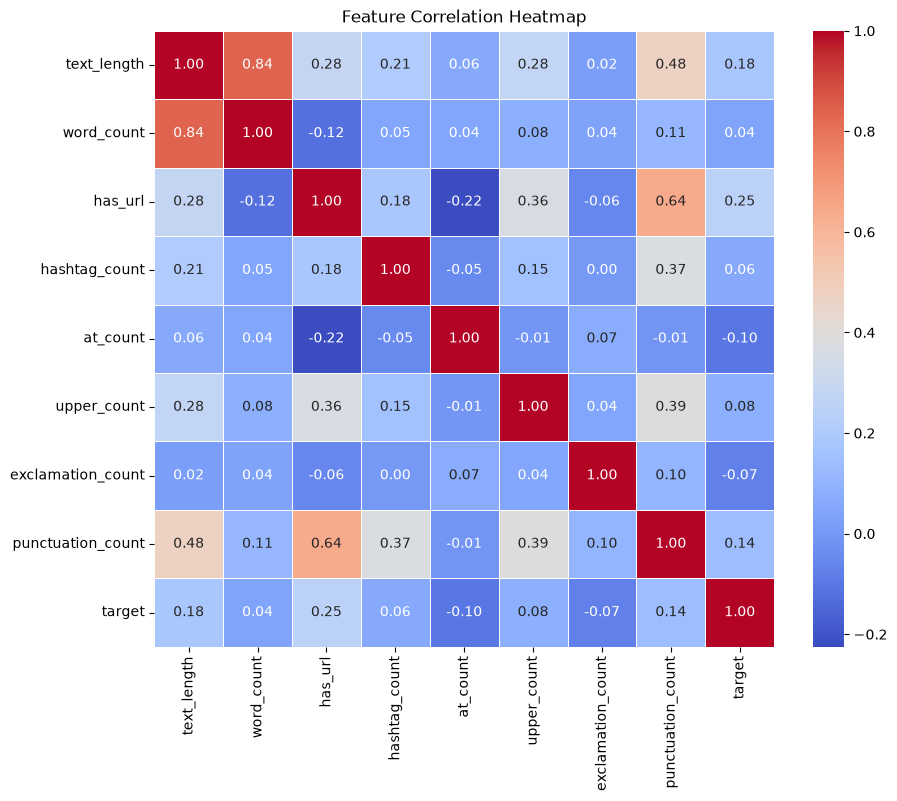

In [34]:
corr_matrix = df[features].corr(numeric_only=True)

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.show()

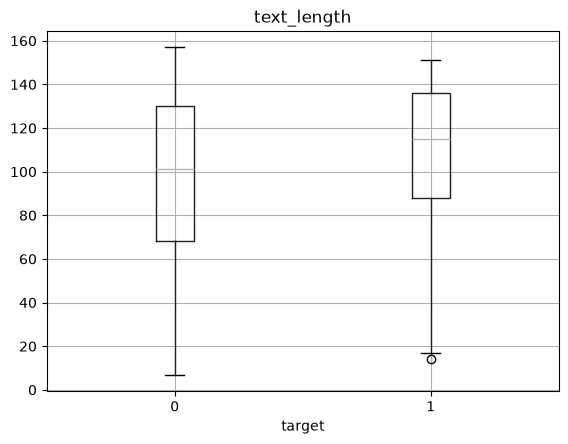

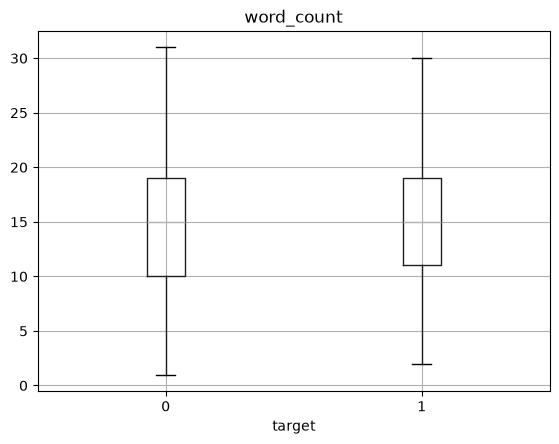

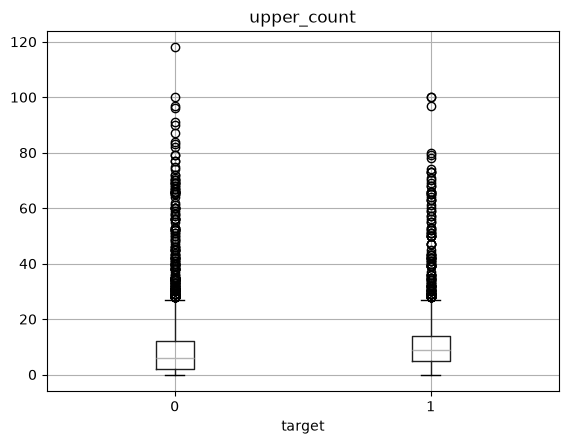

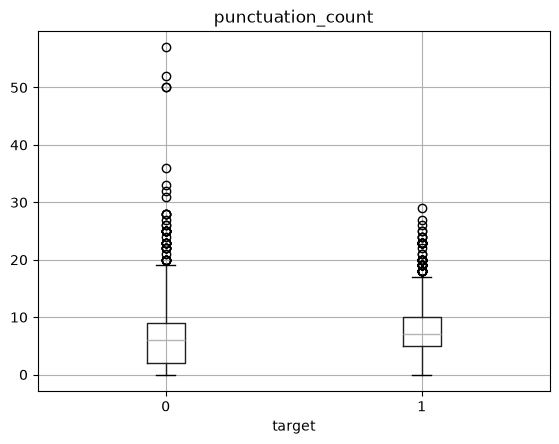

In [35]:
feature_cols = [
    "text_length",
    "word_count",
    "upper_count",
    "punctuation_count"
]

for col in feature_cols:
    df.boxplot(column=col, by="target")
    plt.title(col)
    plt.suptitle("")
    plt.show()

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words="english")#bow for each tweet

X = vectorizer.fit_transform(df["text"])#learns vocab and then bow

mask = (df["target"] == 1).to_numpy()

word_freq = X[mask].sum(axis=0) #contains total occurrences of each word across ALL disaster tweets.

words = vectorizer.get_feature_names_out()#get vocab words

freq_df = pd.DataFrame({
    "word": words,
    "count": word_freq.A1 #matrix([[2, 1, 1, 5, 3]]) stil a 2d matrix therefore flatten to 1d numpy array
})

freq_df.sort_values("count", ascending=False).head(20)

#9192 and 21307... are freq df indices

,word,count
9192,http,2382
21307,û_,172
13050,news,140
1939,amp,135
9193,https,134
5779,disaster,121
3746,california,115
17896,suicide,112
14557,police,109
14216,people,105


In [37]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words="english")

X = vectorizer.fit_transform(df["text"])

mask = (df["target"] == 0).to_numpy()

word_freq = X[mask].sum(axis=0)

words = vectorizer.get_feature_names_out()

freq_df = pd.DataFrame({
    "word": words,
    "count": word_freq.A1
})

freq_df.sort_values("count", ascending=False).head(20)

,word,count
9192,http,1927
9193,https,277
11323,like,254
10427,just,234
1939,amp,209
21307,û_,176
13036,new,170
5970,don,138
3232,body,116
19807,video,96


In [38]:
vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2,2)
)

X = vectorizer.fit_transform(
    df[df["target"]==1]["text"]
)

bigrams = pd.DataFrame({
    "bigram": vectorizer.get_feature_names_out(),
    "count": X.sum(axis=0).A1
})

bigrams.sort_values(
    "count",
    ascending=False
).head(20)

,bigram,count
23440,û_ http,109
20197,suicide bomber,59
15644,northern california,41
15938,oil spill,38
3264,burning buildings,37
20199,suicide bombing,35
3460,california wildfire,34
2845,bomber detonated,30
783,70 years,30
9264,homes razed,29


In [39]:
len(bigrams)

23562

In [40]:
bigrams.sort_values(
    "count",
    ascending=False
).head(20)

,bigram,count
23440,û_ http,109
20197,suicide bomber,59
15644,northern california,41
15938,oil spill,38
3264,burning buildings,37
20199,suicide bombing,35
3460,california wildfire,34
2845,bomber detonated,30
783,70 years,30
9264,homes razed,29


In [41]:
vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2,2)
)

X = vectorizer.fit_transform(
    df[df["target"]==0]["text"]
)

bigrams = pd.DataFrame({
    "bigram": vectorizer.get_feature_names_out(),
    "count": X.sum(axis=0).A1
})

bigrams.sort_values(
    "count",
    ascending=False
).head(20)

,bigram,count
30543,û_ http,108
6012,cross body,39
30428,youtube video,36
17204,liked youtube,35
28713,video http,27
3461,body bag,27
11256,gt gt,26
3463,body bagging,24
30544,û_ https,24
4028,burning buildings,23
